# **Xây dựng mô hình dựa vào thuật toán phân cụm K-Means trên tập dữ liệu Online Retail**

**Student: MANH QUYNH**

In [99]:
import numpy as np 
import pandas as pd 
import seaborn as sns 

In [100]:
import pandas as pd

df = pd.read_csv(
    r"C:/Users/MANH QUYNH/Downloads/Online Retail/OnlineRetail.csv",
    encoding="ISO-8859-1"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [101]:
#Kiểm tra dữ liệu
df.head()

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [102]:
#Kiểm tra Missing Value
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [103]:
#Loại bỏ Missing
df = df.dropna()

In [104]:
#Loại bỏ giao dịch trả hàng
df = df[df['Quantity']>0]
df = df[df['UnitPrice']>0]

In [105]:
#Tạo đặc trưng RFM
#Tính doanh thu
df['TotalPrice']=df['Quantity']*df['UnitPrice']

In [106]:
#Đổi định dạng ngày
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    format="%d-%m-%Y %H:%M"
)

In [107]:
#Ngày tham chiếu
snapshot=df['InvoiceDate'].max()+pd.Timedelta(days=1)

In [108]:
#Tạo bảng RFM
rfm=df.groupby('CustomerID').agg({

'InvoiceDate':lambda x:(snapshot-x.max()).days,

'InvoiceNo':'nunique',

'TotalPrice':'sum'

})

rfm.columns=['Recency','Frequency','Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [109]:
#Chuẩn hóa dữ liệu
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

rfm_scaled=scaler.fit_transform(rfm)

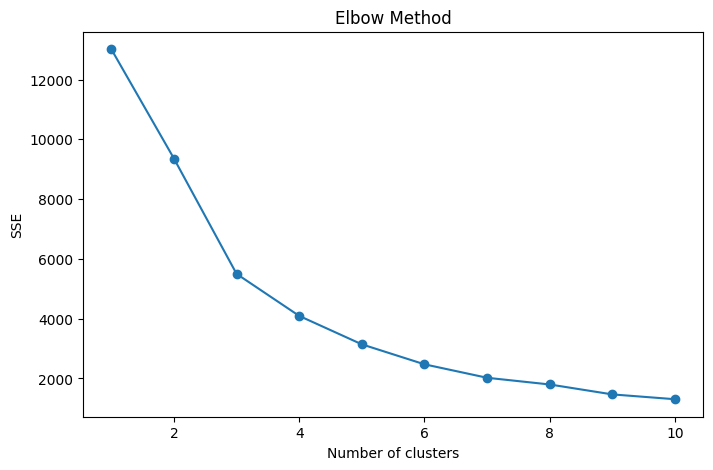

In [110]:
#Xác định số cụm Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse=[]

for k in range(1,11):

    km=KMeans(n_clusters=k,random_state=42)

    km.fit(rfm_scaled)

    sse.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),sse,'o-')

plt.xlabel("Number of clusters")

plt.ylabel("SSE")

plt.title("Elbow Method")

plt.show()

In [111]:
#Silhouette Score
from sklearn.metrics import silhouette_score

for k in range(2,11):

    km=KMeans(n_clusters=k,random_state=42)

    labels=km.fit_predict(rfm_scaled)

    print(k,silhouette_score(rfm_scaled,labels))

2 0.5603671809121974
3 0.5852924318247733
4 0.616212846765192
5 0.617115186725246
6 0.5982715957283189
7 0.51717221452567
8 0.49091567183009177
9 0.484017028247486
10 0.42503454870703994


In [112]:
#Huấn luyện mô hình
kmeans=KMeans(n_clusters=4,random_state=42)

rfm['Cluster']=kmeans.fit_predict(rfm_scaled)

In [113]:
#Phân tích kết quả
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


In [114]:
#Trực quan hóa
from sklearn.decomposition import PCA

pca=PCA(n_components=2)

pca_data=pca.fit_transform(rfm_scaled)

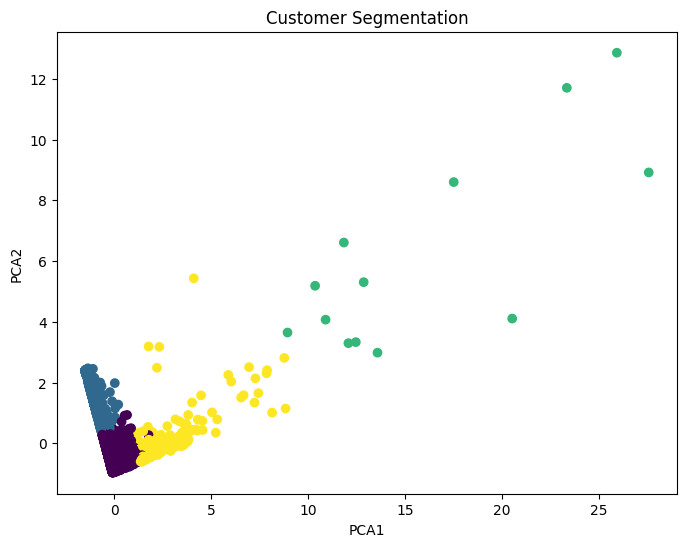

In [115]:
#Vẽ
plt.figure(figsize=(8,6))

plt.scatter(

pca_data[:,0],

pca_data[:,1],

c=rfm['Cluster'],

cmap='viridis'

)

plt.xlabel("PCA1")

plt.ylabel("PCA2")

plt.title("Customer Segmentation")

plt.show()

In [116]:
#Đánh giá mô hình Silhouette Score
score=silhouette_score(rfm_scaled,rfm['Cluster'])

print(score)

0.616212846765192


In [117]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X = pca.fit_transform(rfm_scaled)

In [118]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=0
)

clusters = kmeans.fit_predict(X)

In [119]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [120]:
%pip install -U nbformat ipykernel

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [121]:
import plotly.io as pio

pio.renderers.default = "browser"

In [ ]:

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=X[clusters==0,0],
    y=X[clusters==0,1],
    mode='markers',
    marker_color='#DB4CB2',
    name='Cluster 1'
))

fig.add_trace(go.Scatter(
    x=X[clusters==1,0],
    y=X[clusters==1,1],
    mode='markers',
    marker_color='#C9E9F6',
    name='Cluster 2'
))

fig.add_trace(go.Scatter(
    x=X[clusters==2,0],
    y=X[clusters==2,1],
    mode='markers',
    marker_color='#7D3AC1',
    name='Cluster 3'
))

fig.add_trace(go.Scatter(
    x=kmeans.cluster_centers_[:,0],
    y=kmeans.cluster_centers_[:,1],
    mode='markers',
    marker=dict(
        symbol='x',
        size=13,
        color='black'
    ),
    name='Centroids'
))

fig.update_layout(
    template='plotly_dark',
    width=900,
    height=500,
    title='K-Means Customer Clustering Results'
)

fig.show()